In [1]:
%reload_ext autoreload
%autoreload 2

import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo

import signs_alignment as sa
import os

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

In [2]:
sa.register_all_modules()
model = init_detector(CONFIG_FILE, CHECKPOINT_FILE, device='cuda:0')

Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [3]:
fragments = sa.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0]
print(f"Processing sample: {sample}")

Found 947 fragments with both image and annotation
Processing sample: NBC.4020


In [4]:
# show groud truth boxes

img = sa.load_image(sample)
gt_boxes = sa.load_ground_truth(sample)

gt_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
gt_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))



In [5]:
# sign text
signs_text = sa.get_signs_from_api(sample)
if signs_text is None:
    raise ValueError(f"No sign text found for sample {sample}")
print(f"  Raw API signs (first 50 chars): {signs_text[:50]}...")

text_lines = sa.parse_api_signs(signs_text)
total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")
# print all text lines
text_visualizer = sa.TextVisualizer(text_lines = text_lines)
text_visualizer.write_text_file(filepath = os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

  Raw API signs (first 50 chars): ABZ579 ABZ70 ABZ371 ABZ586 ABZ6
ABZ461 ABZ214 ABZ3...
  Text lines: 22, total signs: 143


/home/jebediahc/anaconda3/envs/cuneiform-ocr/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


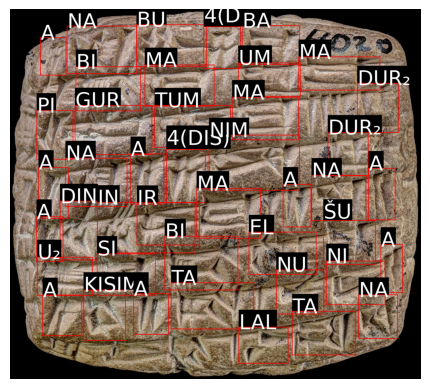

In [6]:
# detect signs
tablet_detector = sa.TabletImageDetector(model, sa.CLASSES, SCORE_THRESHOLD, keep_crops=True)
detections = tablet_detector.detect(img)

det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(255, 0, 0)) # red for detections
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image = cropped[3]

det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.display_result(vis_opt = "draw", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

In [7]:
# statistics
avg_width, avg_height = sa.compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

full image shape: (6451, 5078, 3)
Exp image shape: (1636, 1817, 3)
Average detected sign width: 227.35, height: 196.96


In [8]:
# Build heatmap for position probability of each class

def create_2d_gaussian(center_x, center_y, width, height, sigma_x, sigma_y):
    """Create a 2D Gaussian centered at (center_x, center_y)"""
    x = np.arange(0, width)
    y = np.arange(0, height)
    xx, yy = np.meshgrid(x, y)
    
    gaussian = np.exp(-((xx - center_x)**2 / (2 * sigma_x**2) + 
                        (yy - center_y)**2 / (2 * sigma_y**2)))
    return gaussian

# Get image dimensions and number of classes
img_height, img_width = exp_image.img.shape[:2]
num_classes = len(sa.CLASSES)

print(f"Creating heatmap with shape: ({img_height}, {img_width}, {num_classes})")
print(f"Number of classes: {num_classes}")

# Initialize heatmap
heatmap = np.zeros((img_height, img_width, num_classes), dtype=np.float32)

# Compute influence radius based on average dimensions
influence_radius = (avg_width + avg_height) / 2 * 1.5
sigma_x = influence_radius / 3  # ~99.7% of Gaussian within 3 sigma
sigma_y = influence_radius / 3

print(f"Influence radius: {influence_radius:.2f}, sigma: {sigma_x:.2f}")

# Generate heatmap for each detection
for det in exp_image.detections:
    # Get bounding box and class
    x1, y1, x2, y2 = det['bbox']
    class_id = sa.CLASSES.index(det['abz_name']) 
    
    # Compute center
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    
    # Generate 2D Gaussian and add to corresponding class channel
    gaussian = create_2d_gaussian(center_x, center_y, img_width, img_height, sigma_x, sigma_y)
    heatmap[:, :, class_id] = np.maximum(heatmap[:, :, class_id], gaussian)

print(f"Heatmap generated with {len(exp_image.detections)} detections")
print(f"Heatmap value range: [{heatmap.min():.3f}, {heatmap.max():.3f}]")


Creating heatmap with shape: (1636, 1817, 173)
Number of classes: 173
Influence radius: 318.23, sigma: 106.08
Heatmap generated with 43 detections
Heatmap value range: [0.000, 1.000]


Class ID for sign 'A': 11
Class ID for sign 'NA': 34


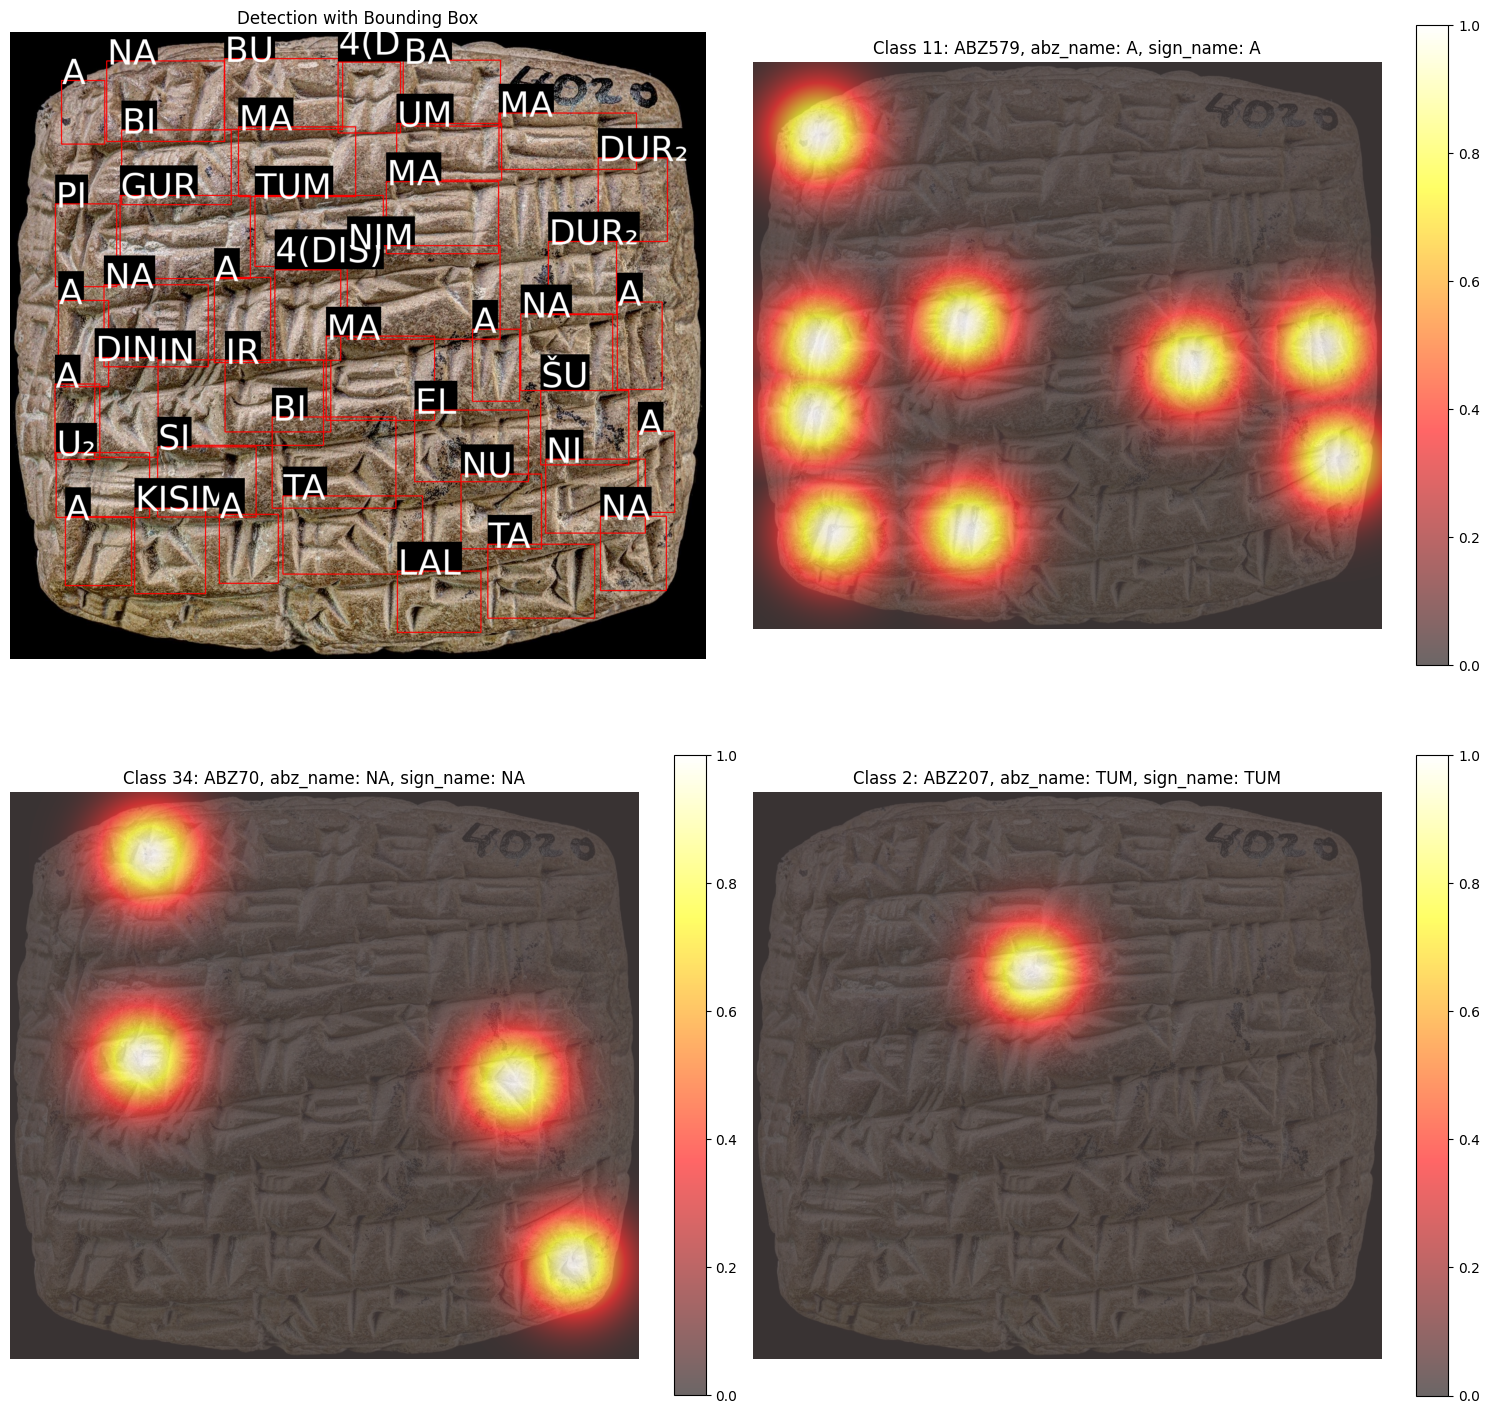

In [16]:
heatmap_visualizer = sa.HeatmapVisualizer()
# find class id for sign name "A"
class_id_for_A = None
class_id_for_NA = None
for i, abz_name in enumerate(sa.CLASSES):
    if sa.abz_to_sign_name(abz_name) == "A":
        class_id_for_A = i
        break
for i, abz_name in enumerate(sa.CLASSES):
    if sa.abz_to_sign_name(abz_name) == "NA":
        class_id_for_NA = i
        break
print(f"Class ID for sign 'A': {class_id_for_A}")
print(f"Class ID for sign 'NA': {class_id_for_NA}")
    
heatmap_visualizer.draw_heatmap(exp_image.img, heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection = exp_image.detections)
heatmap_visualizer.display_result(vis_opt = "draw")